In [9]:
import os
import numpy as np
import xarray as xr
from global_land_mask import globe
import config as cfg

def calc_separate_means():
    print("=== 陆地/海洋差异化分析 (修正版) ===")
    path='../data/2m_temperature_hourly.nc'
    MATRIX_PATH='../matrix__te_t2m_idtxl/'
    # 1. 获取经纬度网格
    if not os.path.exists(path):
        print(f"错误: 找不到数据文件 {path}")
        return

    ds = xr.open_dataset(path)
    lats = ds["latitude"].values
    lons = ds["longitude"].values
    ds.close()
    
    # --- 核心修复：经度转换 ---
    # 如果经度包含大于 180 的值 (0~360格式)，转换为 -180~180
    if np.any(lons > 180):
        print("检测到 0-360 经度格式，正在转换为 -180 到 180 以匹配 land-mask...")
        # 公式：(lon + 180) % 360 - 180
        # 例子：350 -> (530 % 360) - 180 = 170 - 180 = -10 (正确)
        lons_for_mask = (lons + 180) % 360 - 180
    else:
        lons_for_mask = lons

    # 构造网格 (Meshgrid)
    # 注意：这里使用转换后的经度 lons_for_mask
    lon_grid, lat_grid = np.meshgrid(lons_for_mask, lats)
    
    # 2. 生成陆地掩膜 (Land Mask)
    print("正在生成陆地掩膜...")
    # 现在传入的经度都在 -180 到 180 之间，不会报错了
    is_land = globe.is_land(lat_grid, lon_grid)
    
    # 3. 读取 TE 数据
    target_lag = 1
    target_level = 1
    file_name = f"te_map_level_{target_level}_shift_{target_lag}.npy"
    file_path = os.path.join(MATRIX_PATH, file_name)
    
    if not os.path.exists(file_path):
        print(f"数据文件不存在: {file_path}")
        # 为了演示，我们可以先用随机数或者全0代替，或者直接退出
        return
        
    te_map = np.load(file_path)
    
    # 4. 分别提取数据
    # 这里的对应关系依然是正确的，因为我们没有改变数组的形状和顺序
    # 只是修改了用于判断“是不是陆地”的坐标数值
    land_values = te_map[is_land]
    ocean_values = te_map[~is_land]
    
    # 5. 计算均值
    land_mean = np.nanmean(land_values)
    ocean_mean = np.nanmean(ocean_values)
    global_mean = np.nanmean(te_map)
    
    print("-" * 30)
    print(f"分析文件: {file_name}")
    print(f"全  球均值: {global_mean:.4f} bits")
    print(f"陆  地均值: {land_mean:.4f} bits")
    print(f"海  洋均值: {ocean_mean:.4f} bits")
    print("-" * 30)
    
    if land_mean > ocean_mean:
        print(">> 结论: 陆地上的信息流更强。")
    else:
        print(">> 结论: 海洋上的信息流更强。")

    # 6. 验证掩膜 (使用原始经度画图，确保视觉上没问题)
    visualize_mask(is_land, lons, lats)

def visualize_mask(mask, lons, lats):
    """画一下掩膜，确认陆地形状是对的"""
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    
    plt.figure(figsize=(10, 5))
    # 使用 Robinson 投影
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # 画出掩膜
    # 注意：画图时我们可以直接用原始的 lons，cartopy 会自己处理 0-360
    plt.pcolormesh(lons, lats, mask, transform=ccrs.PlateCarree(), cmap='viridis')
    
    ax.coastlines(color='white', linewidth=0.5)
    plt.title("Land Mask Verification (Yellow=Land)")
    
    save_path = "land_mask_check.png"
    plt.savefig(save_path)
    plt.close()
    print(f"掩膜验证图已保存为 {save_path}，请检查黄色区域是否覆盖大陆。")

if __name__ == "__main__":
    calc_separate_means()

=== 陆地/海洋差异化分析 (修正版) ===
检测到 0-360 经度格式，正在转换为 -180 到 180 以匹配 land-mask...
正在生成陆地掩膜...
------------------------------
分析文件: te_map_level_1_shift_1.npy
全  球均值: 0.1634 bits
陆  地均值: 0.1095 bits
海  洋均值: 0.1901 bits
------------------------------
>> 结论: 海洋上的信息流更强。
掩膜验证图已保存为 land_mask_check.png，请检查黄色区域是否覆盖大陆。


=== 开始后处理：生成陆海均值汇总 CSV ===
正在读取文件: ../data/2m_temperature_hourly.nc
检测到 0-360 格式经度，正在标准化为 -180 到 180...
数据预处理完成: 形状=(744, 721, 1440)
正在生成陆地掩膜...
陆海掩膜生成完毕。
汇总数据已保存至: figure_hourly_analysis_1/hourly_summary_land_ocean.csv
=== 开始绘图 ===


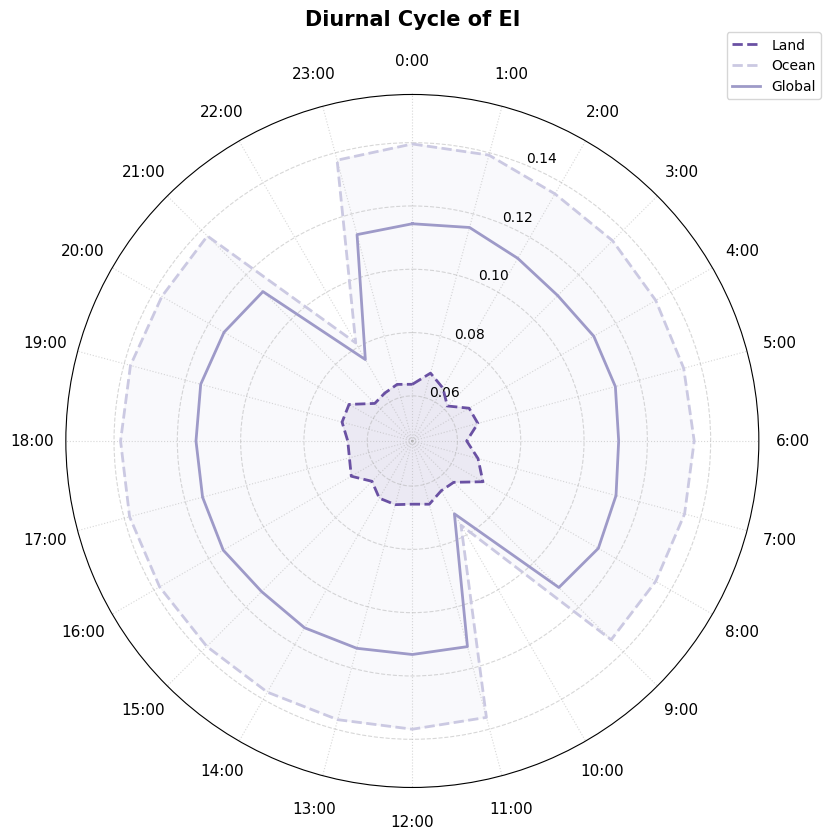

雷达图已保存: figure_hourly_analysis_1/post_radar_comparison.png


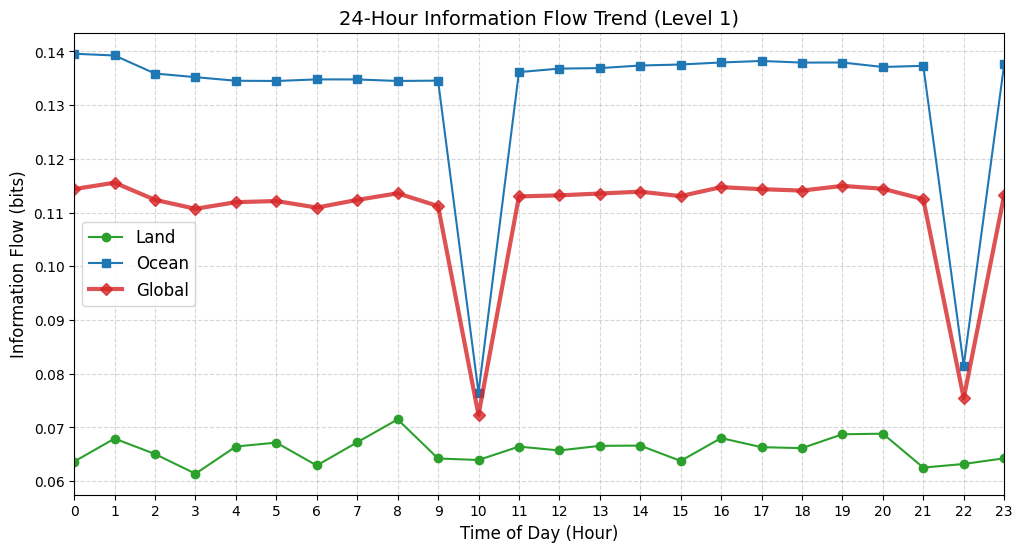

折线图已保存: figure_hourly_analysis_1/post_line_comparison.png


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg
from data_utils import load_nc_data, get_land_mask

# ————————————————————————
# 配置 (请根据您实际生成文件的参数修改)
# ————————————————————————
# 输入目录：存放 .npy 文件的位置
INPUT_DIR = "matrix_hourly_analysis_1" 
# 输出目录：存放图片和 CSV 的位置
OUTPUT_DIR = "figure_hourly_analysis_1"
NC_PATH='../data/2m_temperature_hourly.nc'

# 文件名模式：请确认您的 npy 文件名格式
# 例如: "hourly_te_level1_hour05.npy"
FILE_PATTERN = "hourly_te_level{level}_hour{hour:02d}.npy"
TARGET_LEVEL = 1 

os.makedirs(OUTPUT_DIR, exist_ok=True)

def generate_summary_csv():
    print("=== 开始后处理：生成陆海均值汇总 CSV ===")
    
    # 1. 准备地理掩膜 (只需做一次)
    # 我们需要经纬度来生成掩膜，所以读取一次 NC 文件头信息
    if not os.path.exists(NC_PATH):
        print(f"错误: 找不到原始数据文件 {NC_PATH} (用于生成掩膜)")
        return None

    # 加载经纬度 (不需要加载具体温度数据，days=0 或 1 即可，省内存)
    # 注意：我们只需要 lats 和 lons
    ds = load_nc_data(NC_PATH, cfg.VAR_NAME, days=1) 
    # load_nc_data 返回: temp, lats, lons, lon_shift
    # 我们只需要中间两个
    lats, lons = ds[1], ds[2]
    
    # 生成掩膜
    land_mask = get_land_mask(lats, lons) # True=Land, False=Ocean
    print("陆海掩膜生成完毕。")

    summary_data = []
    
    # 2. 循环处理 24 小时文件
    for h in range(24):
        file_name = FILE_PATTERN.format(level=TARGET_LEVEL, hour=h)
        file_path = os.path.join(INPUT_DIR, file_name)
        
        if not os.path.exists(file_path):
            print(f"警告: 文件缺失 {file_path}，跳过 hour {h}")
            summary_data.append({
                'hour': h, 'global_mean': np.nan, 'land_mean': np.nan, 'ocean_mean': np.nan
            })
            continue
            
        try:
            # 读取数据
            mi_map = np.load(file_path)
            
            # 计算均值 (忽略 NaN)
            global_mean = np.nanmean(mi_map)
            land_mean = np.nanmean(mi_map[land_mask])
            ocean_mean = np.nanmean(mi_map[~land_mask])
            
            summary_data.append({
                'hour': h,
                'global_mean': global_mean,
                'land_mean': land_mean,
                'ocean_mean': ocean_mean
            })
            # print(f"Hour {h:02d} processed.")
            
        except Exception as e:
            print(f"处理出错 hour {h}: {e}")

    # 3. 保存 CSV
    df = pd.DataFrame(summary_data)
    csv_path = os.path.join(OUTPUT_DIR, "hourly_summary_land_ocean.csv")
    df.to_csv(csv_path, index=False)
    print(f"汇总数据已保存至: {csv_path}")
    
    return df

def plot_charts(df):
    """同时绘制雷达图和折线图"""
    print("=== 开始绘图 ===")
    
    # 准备数据
    hours = df['hour'].values
    vals_global = df['global_mean'].values
    vals_land = df['land_mean'].values
    vals_ocean = df['ocean_mean'].values
    
    # 处理缺失值 (简单的线性插值或填充0，防止绘图断裂)
    # 这里假设数据完整，若有NaN matplotlib通常会留白
    
    # ——————————————————————————————————————————————
    # 图表 1: 多线雷达图 (Radar Chart)
    # ——————————————————————————————————————————————
    # 闭合数据
    theta = np.linspace(0.0, 2 * np.pi, len(hours), endpoint=False)
    
    # 将数据首尾相连
    theta_closed = np.concatenate((theta, [theta[0]]))
    v_global_c = np.concatenate((vals_global, [vals_global[0]]))
    v_land_c = np.concatenate((vals_land, [vals_land[0]]))
    v_ocean_c = np.concatenate((vals_ocean, [vals_ocean[0]]))
    
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='polar')
    
    # 设置 0 点在正上方，顺时针
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # 绘图
    # 陆地 (绿色)
    ax.plot(theta_closed, v_land_c, color='#6a51a3', linewidth=2, linestyle='--', label='Land')
    ax.fill(theta_closed, v_land_c, color='#6a51a3', alpha=0.1)
    
    # 海洋 (蓝色)
    ax.plot(theta_closed, v_ocean_c, color='#cbc9e2', linewidth=2, linestyle='--', label='Ocean')
    ax.fill(theta_closed, v_ocean_c, color='#cbc9e2', alpha=0.1)
    
    # 全球 (红色粗线)
    ax.plot(theta_closed, v_global_c, color='#9e9ac8', linewidth=2, label='Global')
    
    # 刻度设置
    ticks = np.arange(0, 24, 1)
    ax.set_xticks(np.radians(ticks * 15))
    ax.set_xticklabels([f"{h}:00" for h in ticks], fontsize=11)
    
    # 动态调整 Y 轴范围以突出差异
    all_vals = np.concatenate([vals_land, vals_ocean])
    valid_vals = all_vals[~np.isnan(all_vals)]
    if len(valid_vals) > 0:
        min_val, max_val = np.min(valid_vals), np.max(valid_vals)
        # 让图形饱满一点，不要从0开始，除非数值很接近0
        margin = (max_val - min_val) * 0.2
        ax.set_ylim(max(0, min_val - margin), max_val + margin)

    # —— 角向刻度（x）——
    ax.set_xticks(np.radians(ticks * 15))
    ax.set_xticklabels([f"{h}:00" for h in ticks], fontsize=11)
    ax.tick_params(axis='x', pad=14)   # ⭐ 推开角向标签

    # —— 径向刻度（y）——
    # ax.set_rlabel_position(225)        # ⭐ 挪走 r 标签
    ax.tick_params(axis='y', pad=8)

    # —— 网格线弱化 ——（可选但推荐）
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.grid(True, linestyle=':', alpha=0.5)


    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.title(f"Diurnal Cycle of EI", fontsize=15, pad=20, fontweight='bold')
    save_radar = os.path.join(OUTPUT_DIR, "post_radar_comparison.png")
    plt.savefig(save_radar, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"雷达图已保存: {save_radar}")

    # ——————————————————————————————————————————————
    # 图表 2: 多线折线图 (Line Chart)
    # ——————————————————————————————————————————————
    plt.figure(figsize=(12, 6))
    
    plt.plot(hours, vals_land, marker='o', markersize=6, color='#2ca02c', label='Land', linestyle='-')
    plt.plot(hours, vals_ocean, marker='s', markersize=6, color='#1f77b4', label='Ocean', linestyle='-')
    plt.plot(hours, vals_global, marker='D', markersize=6, color='#d62728', label='Global', linewidth=3, alpha=0.8)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(np.arange(0, 24, 1)) # 显示每个小时
    plt.xlim(0, 23)
    
    plt.xlabel('Time of Day (Hour)', fontsize=12)
    plt.ylabel('Information Flow (bits)', fontsize=12)
    plt.title(f"24-Hour Information Flow Trend (Level {TARGET_LEVEL})", fontsize=14)
    plt.legend(fontsize=12)

    save_line = os.path.join(OUTPUT_DIR, "post_line_comparison.png")
    plt.savefig(save_line, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"折线图已保存: {save_line}")

if __name__ == "__main__":
    # 1. 生成 CSV
    df_summary = generate_summary_csv()
    
    # 2. 绘图
    if df_summary is not None and not df_summary.empty:
        plot_charts(df_summary)

正在加载 24 小时的 Level 1 数据...
正在绘制 24 小时云雨图...


/home/dm-03/anaconda3/envs/causal/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


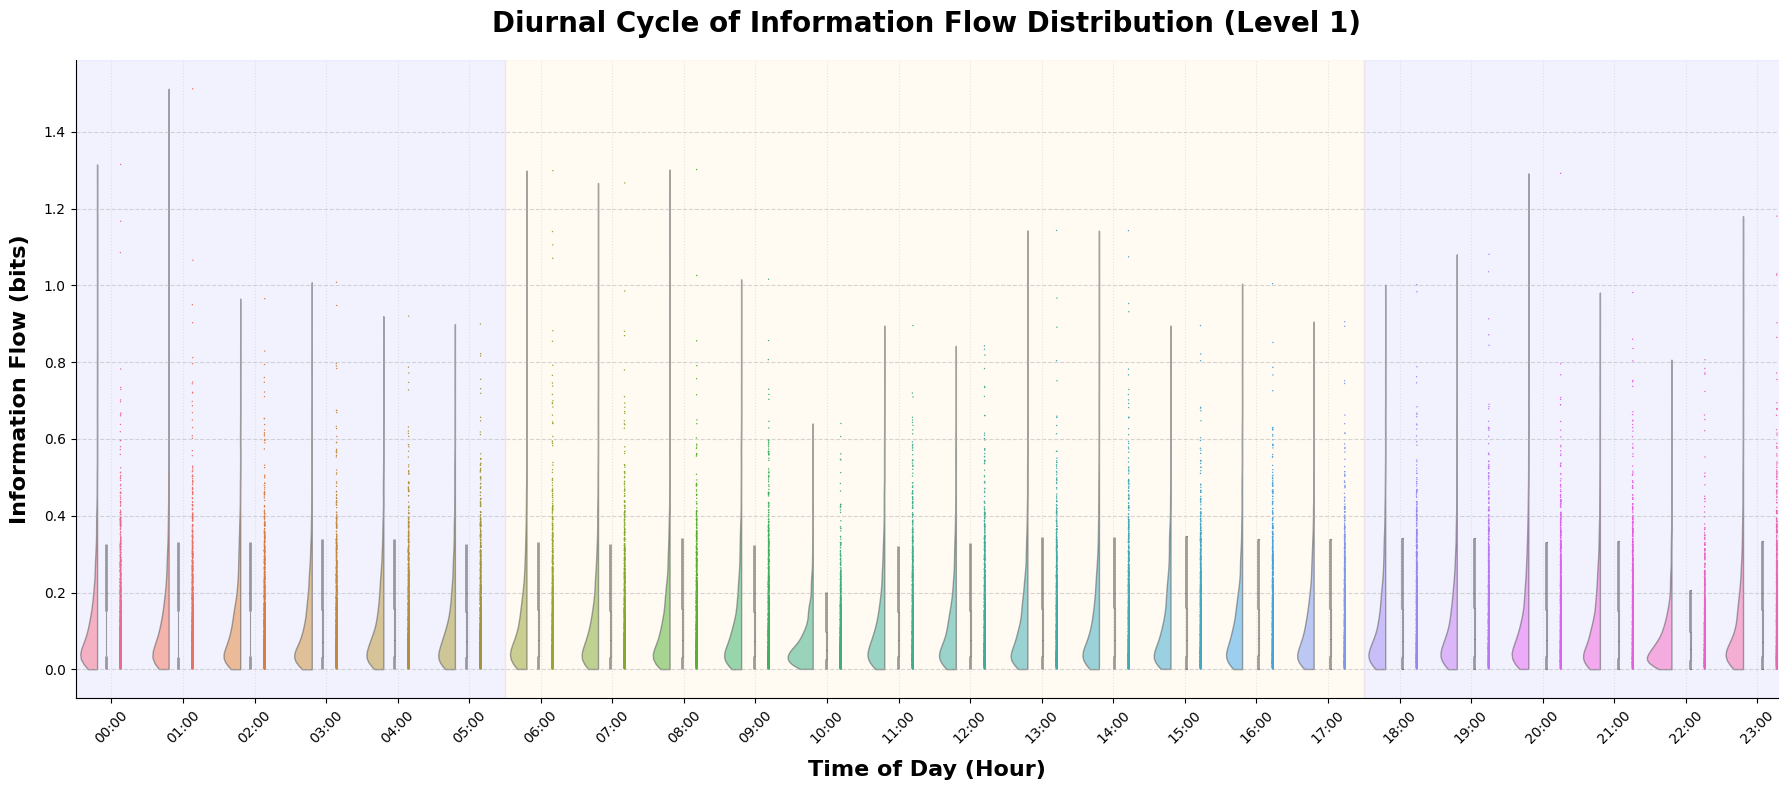

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt 
import config as cfg

# ————————————————————————
# 配置
# ————————————————————————
# 数据源目录 (需与 main_hourly.py 一致)
DATA_DIR = "matrix_hourly_analysis_1"
OUTPUT_DIR = "figure_hourly_analysis_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 目标 Level (通常我们在 main_hourly.py 中固定了一个 Level，比如 Level 1)
# 如果您跑了多个 Level 的小时数据，这里需要指定一个
TARGET_LEVEL = 1 

# 降采样数量 (为了绘图速度和美观，如果点太多图会很乱)
SAMPLE_SIZE = 2000 

def load_hourly_data():
    print(f"正在加载 24 小时的 Level {TARGET_LEVEL} 数据...")
    
    data_list = []
    
    # 遍历 0 到 23 点
    for h in range(24):
        # 文件名格式: hourly_te_level1_hour05.npy
        file_name = f"hourly_te_level{TARGET_LEVEL}_hour{h:02d}.npy"
        file_path = os.path.join(DATA_DIR, file_name)
        
        if os.path.exists(file_path):
            try:
                # 读取数据
                mi_map = np.load(file_path)
                
                # 展平并移除 NaN
                values = mi_map.flatten()
                valid_values = values[~np.isnan(values)]
                
                # 随机降采样
                if len(valid_values) > SAMPLE_SIZE:
                    valid_values = np.random.choice(valid_values, SAMPLE_SIZE, replace=False)
                
                # 添加到列表
                # 注意：Hour 是类别变量
                for v in valid_values:
                    data_list.append({'Hour': h, 'EI': v})
                    
            except Exception as e:
                print(f"读取 Hour {h} 出错: {e}")
        else:
            print(f"文件缺失: {file_name}")
            
    return pd.DataFrame(data_list)

def plot_hourly_raincloud(df):
    if df.empty:
        print("没有数据可绘图。")
        return

    print("正在绘制 24 小时云雨图...")
    
    # 设置画布
    # 24 个组比较宽，需要足够的宽度
    fig_width = 18
    f, ax = plt.subplots(figsize=(fig_width, 8))

    # 定义配色
    # 使用循环色系 (例如 'twilight' 或 'hsv') 来体现日循环的感觉
    # 或者用冷暖色调 (白天暖色，晚上冷色)
    # 这里使用 husl 保证颜色区分度
    palette = sns.color_palette("husl", n_colors=24)

    # 绘制云雨图
    pt.RainCloud(x="Hour", y="EI", data=df,
                 palette=palette,
                 bw=0.2,                 # 带宽
                 width_viol=0.7,         # 云宽度
                 width_box=0.15,         # 箱线图宽度
                 ax=ax,
                 orient='v',
                 alpha=0.5,              # 散点透明度
                 dodge=True,
                 point_plot=True,        # 显示均值连线 (展示日变化趋势)
                 point_size=1.0,         # 散点小一点
                 move=0.2,
                 box_showfliers=False,
                 box_linewidth=0.8)

    # ————————————————————————
    # 美化
    # ————————————————————————
    ax.set_title(f"Diurnal Cycle of Information Flow Distribution (Level {TARGET_LEVEL})", 
                 fontsize=20, fontweight='bold', pad=20)
    
    ax.set_xlabel("Time of Day (Hour)", fontsize=16, fontweight='bold', labelpad=10)
    ax.set_ylabel("Information Flow (bits)", fontsize=16, fontweight='bold', labelpad=10)
    
    # 设置 X 轴刻度标签
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], fontsize=10, rotation=45)
    
    # 添加网格线
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.grid(axis='x', linestyle=':', alpha=0.3)
    
    # 去除多余边框
    sns.despine()
    
    # 添加日夜背景 (可选)
    # 假设 6:00-18:00 是白天 (浅黄色背景)，其他是夜晚 (浅蓝色背景)
    # 这是一个视觉增强，如果不喜欢可以注释掉
    ylim = ax.get_ylim()
    # 夜晚 1 (0-6)
    ax.fill_between([-0.5, 5.5], ylim[0], ylim[1], color='blue', alpha=0.05, zorder=0, label='Night')
    # 白天 (6-18)
    ax.fill_between([5.5, 17.5], ylim[0], ylim[1], color='orange', alpha=0.05, zorder=0, label='Day')
    # 夜晚 2 (18-23)
    ax.fill_between([17.5, 23.5], ylim[0], ylim[1], color='blue', alpha=0.05, zorder=0)
    
    # 恢复 Y 轴范围 (fill_between 可能会改变它)
    ax.set_ylim(ylim)
    # ax.set_xlim(-0.5, 23.5)

    plt.tight_layout()
    plt.show()
    # # 保存
    # save_path = os.path.join(OUTPUT_DIR, f"raincloud_hourly_cycle_level{TARGET_LEVEL}.png")
    # plt.savefig(save_path, dpi=300)
    # plt.close()
    
    # print(f"24小时云雨图已保存: {save_path}")

if __name__ == "__main__":
    # 1. 加载数据
    df = load_hourly_data()
    
    # 2. 绘图
    plot_hourly_raincloud(df)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature.nightshade import Nightshade
import datetime
import config as cfg

# ————————————————————————
# 配置
# ————————————————————————
DATA_DIR = "matrix_hourly_analysis"
OUTPUT_DIR = "figure_hourly_custom_color"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_LEVEL = 1  
YEAR = 2023       
MONTH = 1         
DAY = 15          

def plot_enhanced_maps():
    print("=== 开始绘制自定义配色日照分析图 ===")
    
    # 1. 定义自定义颜色列表
    # 您提供了 8 个颜色，对应 levels 定义的 8 个基础区间
    # 为了支持 extend='max' (即 >0.8 的部分)，我们需要第 9 个颜色
    # 这里我们复用最后一个颜色，或者您可以换成更深的颜色
    hex_colors = [
        "#84c3b7", # 0.3 - 0.4
        "#88d8db", # 0.4 - 0.5
        "#71b7ed", # 0.5 - 0.6
        "#b8aeeb", # 0.6 - 0.7
        "#f2a7da", # 0.7 - 0.8
        "#fae69e", # 0.2 - 0.3
        "#f2b56f", # 0.1 - 0.2
        "#f57c6e", # 0.0 - 0.1
        "#f57c6e", # 0.0 - 0.1
    ]
    
    # 创建离散色带
    # name='custom_pastel' 是给这个色带起个名字
    cmap = ListedColormap(hex_colors, name='custom_pastel')
    
    # 2. 定义分界点 (9个数值，形成8个基础区间)
    levels = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.8]
    
    # 使用 BoundaryNorm 将数值映射到颜色
    # ncolors=cmap.N (现在是9) 必须 >= bin数量 (8个基础 + 1个扩展 = 9)
    # extend='max' 会给色条加个箭头，表示超过0.8的值
    norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='max')

    # 3. 准备经纬度 (模拟生成，实际应与 load_nc_data 逻辑一致)
    sample_file = os.path.join(DATA_DIR, f"hourly_te_level{TARGET_LEVEL}_hour00.npy")
    if not os.path.exists(sample_file):
        print(f"找不到示例文件: {sample_file}")
        return
        
    sample_data = np.load(sample_file)
    nlat, nlon = sample_data.shape
    
    # 重建经纬度网格 (ERA5 标准: 90->-90, 0->360)
    lats = np.linspace(90, -90, nlat)
    lons = np.linspace(0, 360, nlon)
    
    # 4. 循环 24 小时绘图
    for h in range(24):
        file_name = f"hourly_te_level{TARGET_LEVEL}_hour{h:02d}.npy"
        file_path = os.path.join(DATA_DIR, file_name)
        
        if not os.path.exists(file_path):
            continue
            
        print(f"正在处理 Hour {h:02d}...")
        
        # 读取数据并修正负值
        mi_map = np.load(file_path)
        mi_map[mi_map < 0] = 0
        
        # 计算全球平均值
        global_avg = np.mean(mi_map)
        
        # 创建画布 (Robinson 投影, 非洲居中)
        fig = plt.figure(figsize=(12, 7))
        proj = ccrs.Robinson(central_longitude=0)
        ax = fig.add_subplot(1, 1, 1, projection=proj)
        
        # A. 绘制 EI 分布 (使用自定义 cmap)
        im = ax.pcolormesh(lons, lats, mi_map,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap,
                           norm=norm) 
        
        # B. 添加地理底图
        # 线条颜色设为深灰色，避免干扰柔和的背景色
        ax.coastlines(resolution='110m', linewidth=0.6, color='#444444', alpha=0.6)
        # ——————————————————————————————————————————————
        # [新增] 添加经纬度网格线
        # ——————————————————————————————————————————————
        gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                          draw_labels=False,  # Robinson 投影建议不画标签，只画线，否则会乱
                          linewidth=0.5, 
                          color='gray', 
                          alpha=0.4, 
                          linestyle='--')
        
        # 设置网格密度：经度每 60 度一根，纬度每 30 度一根
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
        gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

        # C. 添加晨昏线 (Nightshade)
        current_time = datetime.datetime(YEAR, MONTH, DAY, h, 0, 0)
        # alpha=0.15: 稍微调淡一点阴影，让您的自定义颜色更透亮
        ax.add_feature(Nightshade(current_time, alpha=0.15))
        
        # D. 添加色条
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, 
                            spacing='uniform', extend='max')
        cbar.set_label('Information Flow (bits)', fontsize=12)
        
        # E. 标题
        plt.title(f"Global Information Flow at UTC {h:02d}:00\nGlobal Avg = {global_avg:.4f} bits", 
                  fontsize=14, fontweight='bold')
        
        # 保存
        save_path = os.path.join(OUTPUT_DIR, f"custom_color_map_hour{h:02d}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

if __name__ == "__main__":
    plot_enhanced_maps()

=== 开始绘制自定义配色日照分析图 ===
正在处理 Hour 00...
正在处理 Hour 01...
正在处理 Hour 02...
正在处理 Hour 03...
正在处理 Hour 04...
正在处理 Hour 05...
正在处理 Hour 06...
正在处理 Hour 07...
正在处理 Hour 08...
正在处理 Hour 09...
正在处理 Hour 10...
正在处理 Hour 11...
正在处理 Hour 12...
正在处理 Hour 13...
正在处理 Hour 14...
正在处理 Hour 15...
正在处理 Hour 16...
正在处理 Hour 17...
正在处理 Hour 18...
正在处理 Hour 19...
正在处理 Hour 20...
正在处理 Hour 21...
正在处理 Hour 22...
正在处理 Hour 23...


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature.nightshade import Nightshade
import datetime

# ——————————————————————————————————————————————
# 1. 配置参数
# ——————————————————————————————————————————————
DATA_DIR = "matrix_hourly_analysis_1"
OUTPUT_DIR = "figure_hourly_analysis_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_LEVEL = 1  
FILE_PATTERN = "hourly_te_level{level}_hour{hour:02d}.npy"

SIM_YEAR = 2014
SIM_MONTH = 1
SIM_DAY = 15

# ——————————————————————————————————————————————
# 2. 配色方案设置 (修改重点)
# ——————————————————————————————————————————————
def get_colormap_config(style='discrete'):
    """
    获取系统自带的色带配置。
    
    参数:
        style: 'discrete' (分段，推荐) 或 'smooth' (平滑)
    """
    # 1. 选择系统色带名称
    # 推荐: 'turbo' (彩虹增强版), 'viridis' (蓝绿黄), 'plasma' (紫红黄), 'Spectral_r' (红黄蓝)
    cmap_name = 'Blues' 
    cmap = plt.get_cmap(cmap_name)
    
    # 2. 设置数值范围
    # 您的数据大多在 0.05-0.25，但为了展示极值，我们将上限设为 0.8
    # 超过 0.8 的部分会显示为色带顶端的颜色（配合 extend='max'）
    vmin = 0.0
    vmax = 0.6
    
    if style == 'discrete':
        # === 模式 A: 分段离散 (类似等高线，强烈推荐用于观察分布区间) ===
        # 定义您想要的分界点
        levels = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
        
        # 使用 BoundaryNorm
        # ncolors=cmap.N 表示从整个渐变色带中均匀采样出对应数量的颜色
        norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='max')
        
    else:
        # === 模式 B: 平滑渐变 ===
        levels = None # 平滑模式不需要 levels
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        
    return cmap, norm, levels

# ——————————————————————————————————————————————
# 3. 绘图主逻辑
# ——————————————————————————————————————————————
def visualize_all_hours():
    print(f"=== 开始可视化 (使用系统色带) ===")
    
    # 获取配色配置
    # style='discrete': 分段显示 (色块)
    # style='smooth':   平滑显示 (渐变)
    cmap, norm, levels = get_colormap_config(style='discrete')
    
    # 获取网格形状
    sample_file = os.path.join(DATA_DIR, FILE_PATTERN.format(level=TARGET_LEVEL, hour=0))
    if not os.path.exists(sample_file):
        print(f"错误: 找不到示例文件 {sample_file}")
        return

    sample_data = np.load(sample_file)
    nlat, nlon = sample_data.shape
    lats = np.linspace(90, -90, nlat)
    lons = np.linspace(0, 360, nlon)

    # 循环 24 小时
    for h in range(24):
        file_name = FILE_PATTERN.format(level=TARGET_LEVEL, hour=h)
        file_path = os.path.join(DATA_DIR, file_name)
        
        if not os.path.exists(file_path):
            continue
            
        print(f"正在绘图: Hour {h:02d} ...")
        
        try:
            mi_map = np.load(file_path)
            mi_map[mi_map < 0] = 0
            global_avg = np.nanmean(mi_map)
            
            fig = plt.figure(figsize=(12, 7))
            proj = ccrs.Robinson(central_longitude=0)
            ax = fig.add_subplot(1, 1, 1, projection=proj)
            
            # 绘制热力图
            im = ax.pcolormesh(lons, lats, mi_map,
                               transform=ccrs.PlateCarree(),
                               cmap=cmap,
                               norm=norm)
            
            # 地理要素
            ax.coastlines(resolution='110m', linewidth=0.6, color='#404040', alpha=0.8)
            
            # 晨昏线
            current_time = datetime.datetime(SIM_YEAR, SIM_MONTH, SIM_DAY, h, 0, 0)
            ax.add_feature(Nightshade(current_time, alpha=0.15))
            
            # 经纬网格
            gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                              linewidth=0.5, color='#707070', alpha=0.3, linestyle='-')
            gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
            gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))
            
            # 色条设置
            # 如果是分段模式，spacing='uniform' 会让色条上的每一段等宽，方便阅读
            cbar_spacing = 'uniform' if levels is not None else 'proportional'
            
            cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.5, pad=0.05,
                                spacing=cbar_spacing, extend='max')
            cbar.set_label('EI (bits)', fontsize=11)
            
            # plt.title(f"Global Information Flow at UTC {h:02d}:00\nGlobal Avg = {global_avg:.4f} bits", 
            #           fontsize=14, fontweight='bold')
            plt.title(f"Global EI at UTC {h:02d}:00", 
                      fontsize=14, fontweight='bold')
            save_name = f"viz_hour{h:02d}_blues_color.png"
            plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=300, bbox_inches='tight')
            plt.close()
            
        except Exception as e:
            print(f"绘图出错 {h:02d}: {e}")

    print("\n=== 完成 ===")

if __name__ == "__main__":
    visualize_all_hours()

=== 开始可视化 (使用系统色带) ===
正在绘图: Hour 00 ...
正在绘图: Hour 01 ...
正在绘图: Hour 02 ...
正在绘图: Hour 03 ...
正在绘图: Hour 04 ...
正在绘图: Hour 05 ...
正在绘图: Hour 06 ...
正在绘图: Hour 07 ...
正在绘图: Hour 08 ...
正在绘图: Hour 09 ...
正在绘图: Hour 10 ...
正在绘图: Hour 11 ...
正在绘图: Hour 12 ...
正在绘图: Hour 13 ...
正在绘图: Hour 14 ...
正在绘图: Hour 15 ...
正在绘图: Hour 16 ...
正在绘图: Hour 17 ...
正在绘图: Hour 18 ...
正在绘图: Hour 19 ...
正在绘图: Hour 20 ...
正在绘图: Hour 21 ...
正在绘图: Hour 22 ...
正在绘图: Hour 23 ...

=== 完成 ===
